# Country Segmentation using Unsupervised Machine Learning

## Problem Statement

HELP International is an NGO that aims to provide financial assistance to countries facing socio-economic challenges.

The organization wants to identify countries that require the most aid based on various health and economic indicators.

Since there is no target variable indicating whether a country needs aid or not, we will use Unsupervised Machine Learning techniques to discover hidden patterns in the data.

## Objective

The main objective of this project is to group countries with similar characteristics and identify those that require immediate financial assistance.

## Machine Learning Workflow

1. Data Ingestion
2. Data Understanding
3. Data Validation
4. Exploratory Data Analysis
5. Data Preprocessing
6. Feature Scaling
7. Dimensionality Reduction using PCA
8. K-Means Clustering
9. Cluster Evaluation
10. Cluster Profiling
11. Identification of Countries Requiring Aid
12. Saving Pipeline Components

# Import Required Libraries

In this section, we import all the libraries required for data manipulation, visualization, preprocessing, dimensionality reduction, clustering, and model persistence.

In [33]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import joblib

import warnings
warnings.filterwarnings("ignore")

# Data Ingestion

The first step in any machine learning project is loading the dataset.

We will load the country-level socio-economic dataset into a Pandas DataFrame for further analysis.

In [34]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv
/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/data-dictionary.csv


In [35]:
import pandas as pd

df = pd.read_csv(
    "/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv"
)

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


# Understanding the Dataset

Before performing any analysis, it is important to understand the structure of the dataset.

We will examine:

- Number of rows and columns
- Data types
- Statistical summary

In [36]:
print("Shape of Dataset:", df.shape)

df.info()

Shape of Dataset: (167, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [37]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


# Data Validation

Data quality plays an important role in machine learning.

We will check:

- Missing values
- Duplicate records

This helps ensure that the dataset is clean before proceeding.

In [38]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [39]:
df.duplicated().sum()

np.int64(0)

# Exploratory Data Analysis (EDA)

EDA helps us understand the distribution of variables and uncover patterns hidden within the dataset.

We will analyze:

- Distribution of numerical variables
- Correlation among features
- Presence of outliers

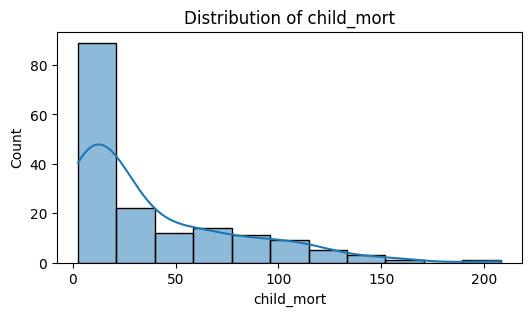

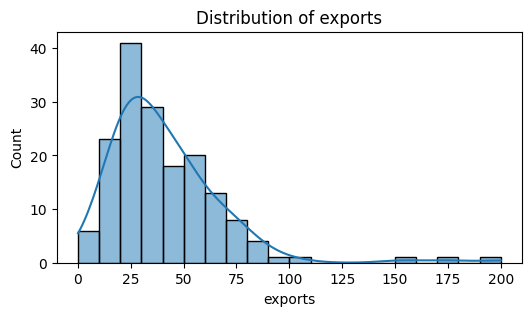

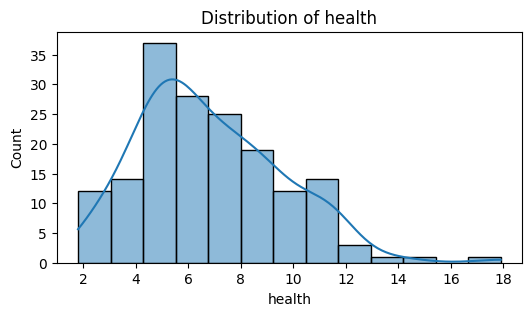

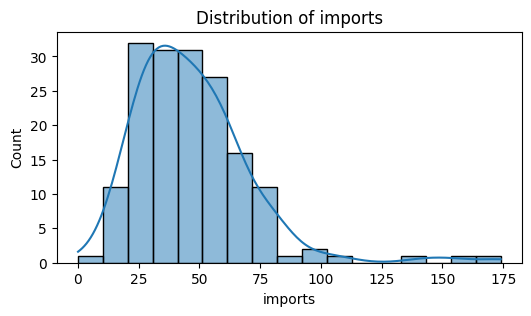

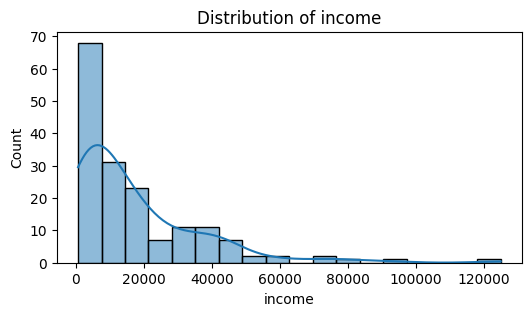

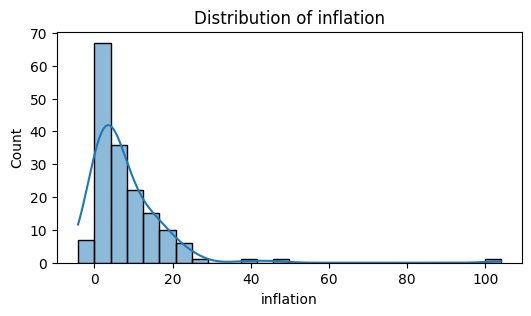

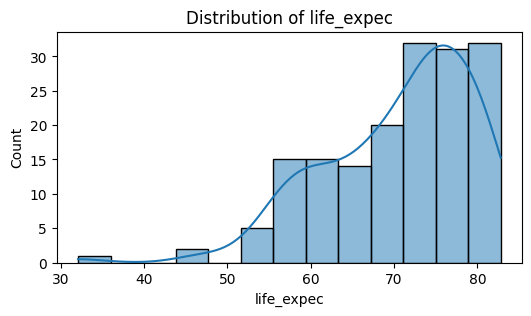

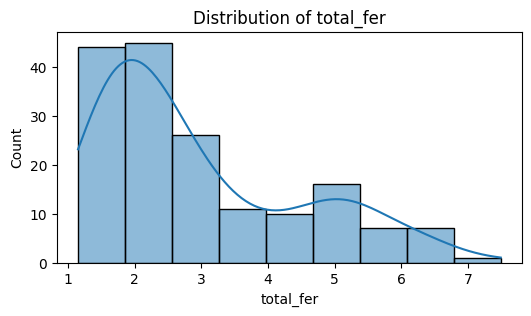

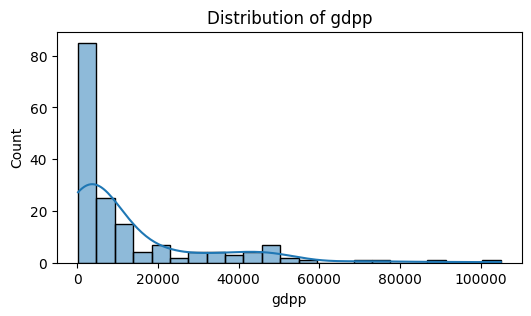

In [40]:
num_cols = df.columns[1:]

for col in num_cols:

    plt.figure(figsize=(6,3))

    sns.histplot(df[col], kde=True)

    plt.title(f"Distribution of {col}")

    plt.show()

# Correlation Analysis

Correlation analysis helps us understand relationships between variables.

Strong positive or negative correlations may reveal important patterns within the data.

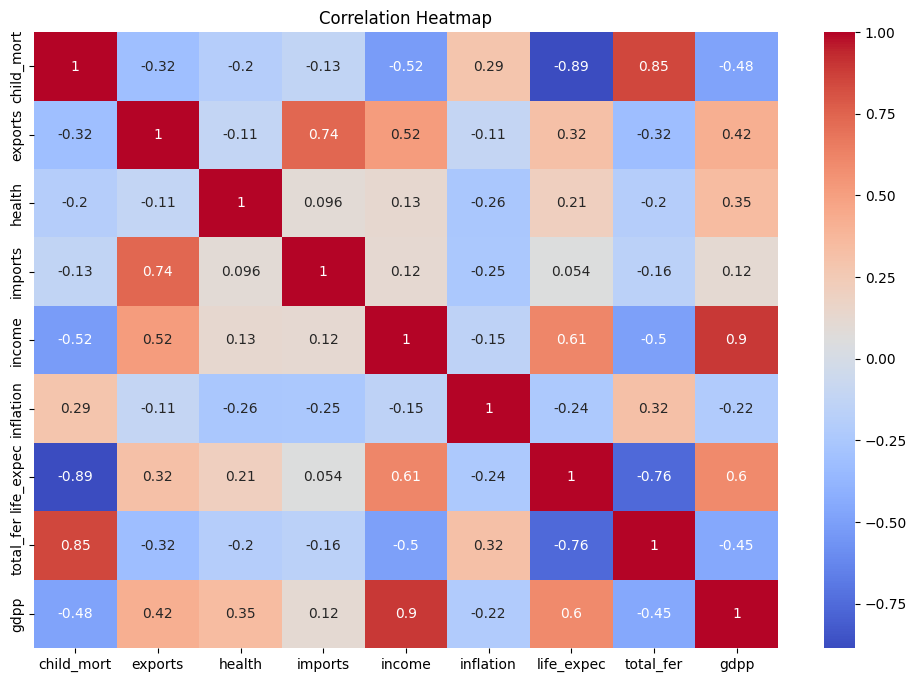

In [41]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.iloc[:,1:].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# Outlier Detection

Country-level economic data often contains extreme values.

Boxplots help visualize outliers present in each feature.

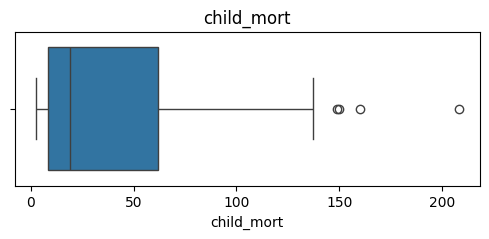

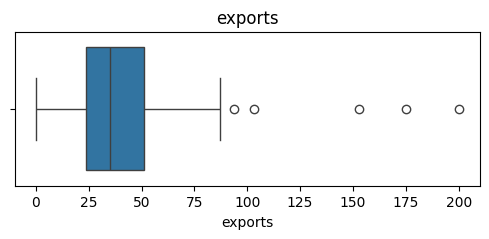

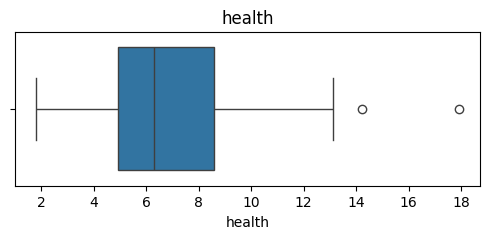

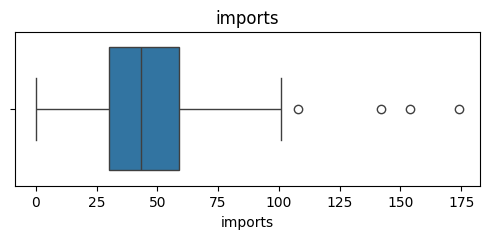

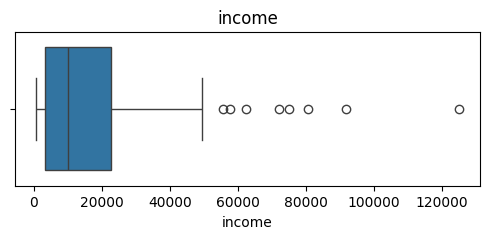

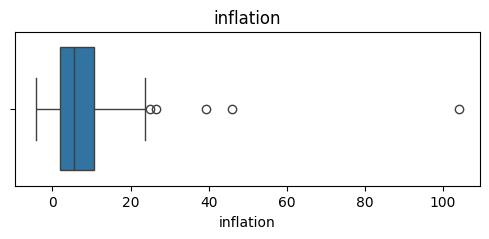

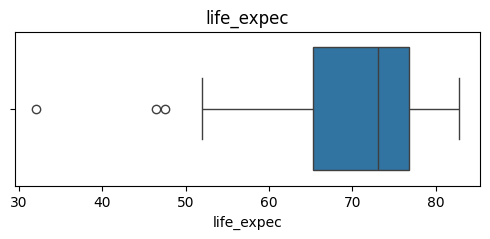

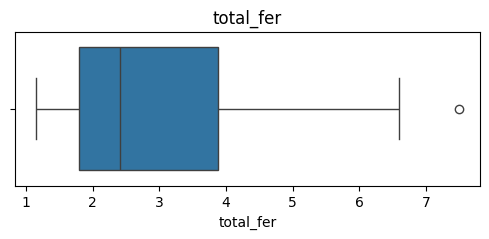

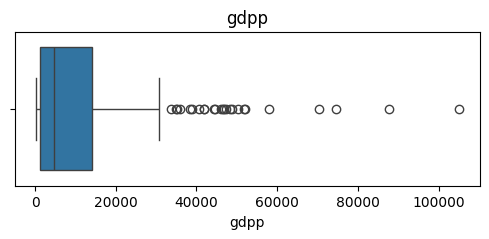

In [42]:
for col in num_cols:

    plt.figure(figsize=(6,2))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

# Feature Selection

The country column is a categorical identifier and cannot be used directly in clustering.

Therefore, we retain only numerical features for model training.

In [43]:
X = df.drop("country", axis=1)

X.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


# Feature Scaling

Features in the dataset have different ranges.

For example:

- Income may be in thousands
- Inflation may be single-digit values

Since K-Means is distance-based, all features must be brought to a common scale.

In [44]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled.shape

(167, 9)

# Dimensionality Reduction using PCA

The dataset contains multiple features.

PCA helps reduce dimensionality while preserving most of the information present in the data.

Benefits:

- Faster computation
- Reduced noise
- Better visualization

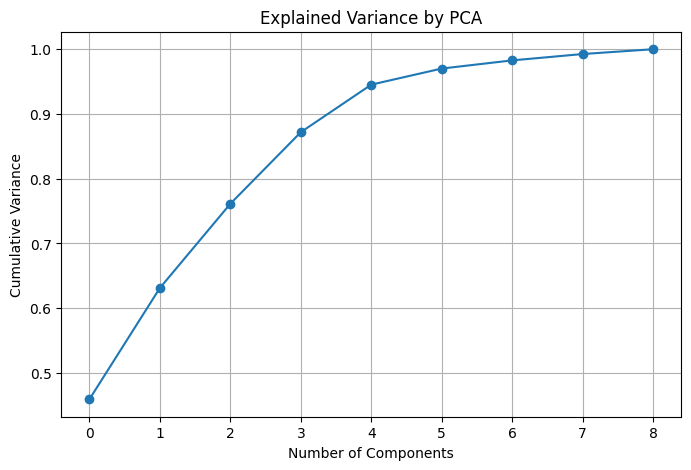

In [45]:
pca = PCA()

X_pca = pca.fit_transform(X_scaled)

explained_variance = np.cumsum(
    pca.explained_variance_ratio_
)

plt.figure(figsize=(8,5))

plt.plot(
    explained_variance,
    marker='o'
)

plt.xlabel("Number of Components")

plt.ylabel("Cumulative Variance")

plt.title("Explained Variance by PCA")

plt.grid()

plt.show()

In [46]:
pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X_scaled)

print("Original Features:", X_scaled.shape[1])

print("Reduced Features:", X_pca.shape[1])

Original Features: 9
Reduced Features: 6


In [47]:
pca_loadings = pd.DataFrame(
    pca.components_,
    columns=X.columns
)

pca_loadings

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,-0.419519,0.283897,0.150838,0.161482,0.398441,-0.193173,0.425839,-0.403729,0.392645
1,0.192884,0.613163,-0.243087,0.671821,0.022536,-0.008404,-0.222707,0.155233,-0.046022
2,-0.029544,0.144761,-0.596632,-0.299927,0.301548,0.642520,0.113919,0.019549,0.122977
3,0.370653,0.003091,0.461897,-0.071907,0.392159,0.150442,-0.203797,0.378304,0.531995
4,-0.168970,0.057616,0.518000,0.255376,-0.247150,0.714869,0.108220,-0.135262,-0.180167
5,-0.200628,0.059333,-0.007276,0.030032,-0.160347,-0.066285,0.601127,0.750689,-0.016779


# Finding the Optimal Number of Clusters

K-Means requires us to specify the number of clusters beforehand.

The Elbow Method helps determine a suitable value of K.

In [48]:
wcss = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_pca)

    wcss.append(model.inertia_)

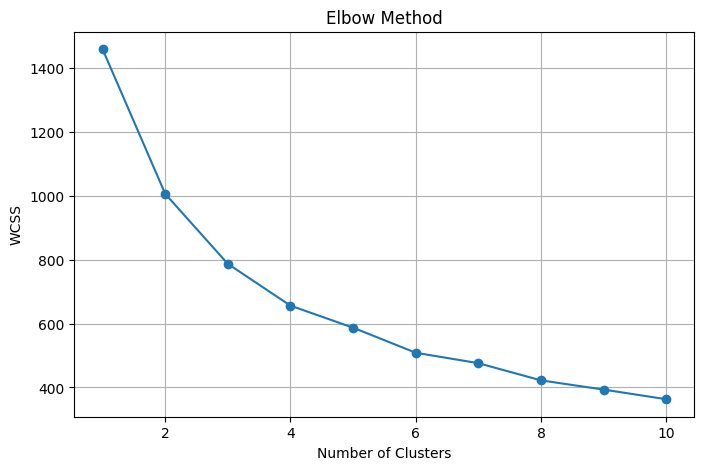

In [49]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.grid()

plt.show()

# Cluster Evaluation using Silhouette Score

The Silhouette Score measures how well-separated clusters are.

A higher score indicates better clustering quality.

In [50]:
scores = []

for k in range(2,8):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_pca)

    score = silhouette_score(
        X_pca,
        labels
    )

    scores.append(score)

    print(
        f"K = {k}, Score = {score:.3f}"
    )

K = 2, Score = 0.296
K = 3, Score = 0.297
K = 4, Score = 0.316
K = 5, Score = 0.238
K = 6, Score = 0.247
K = 7, Score = 0.210


In [51]:
best_k = 2 + np.argmax(scores)

print("Best K:", best_k)

Best K: 4


# Building the Final K-Means Model

Using the optimal number of clusters obtained above, we train the final clustering model.

In [52]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_pca)

df["Cluster"] = clusters

# Visualizing Clusters

Since humans cannot visualize high-dimensional data, we use PCA to project the data into two dimensions and visualize cluster separation.

In [53]:
pca_vis = PCA(n_components=2)

X_vis = pca_vis.fit_transform(X_scaled)

vis_df = pd.DataFrame(
    X_vis,
    columns=["PC1","PC2"]
)

vis_df["Cluster"] = clusters

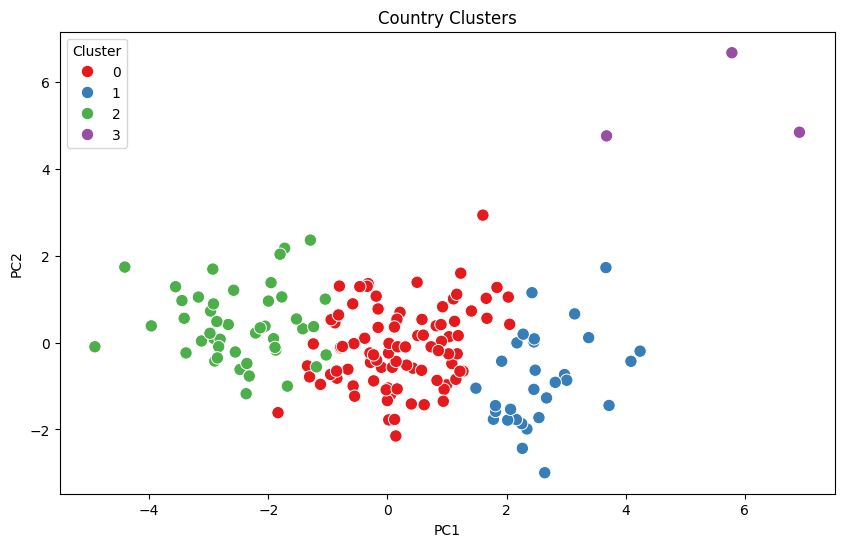

In [54]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=vis_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1",
    s=80
)

plt.title("Country Clusters")

plt.show()

In [55]:
centroids = pd.DataFrame(
    scaler.inverse_transform(
        pca.inverse_transform(
            kmeans.cluster_centers_
        )
    ),
    columns=X.columns
)

centroids

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,22.157138,41.237078,6.250148,48.153508,12790.726003,7.440379,72.824304,2.285596,7085.929538
1,4.063730,46.656934,9.211567,39.079649,45577.869668,2.683948,80.205201,1.811840,42817.308343
2,94.083258,28.422507,6.329717,42.446228,3697.639373,12.112504,59.286797,5.050220,1978.356398
3,-2.823315,176.397604,6.897653,156.080405,66717.203514,2.372998,80.304174,1.504064,55309.518693


# Cluster Profiling

To understand each cluster, we calculate average values of all features within each cluster.

This helps us interpret the economic and health conditions represented by each group.

In [56]:
cluster_summary = df.groupby(
    "Cluster"
).mean(
    numeric_only=True
)

cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,21.743182,41.316920,6.259318,48.075749,12972.386364,7.430580,72.755682,2.293295,6912.636364
1,4.953333,45.826667,9.168667,39.736667,45250.000000,2.742200,80.376667,1.795333,43333.333333
2,93.841304,28.837174,6.346957,42.128261,3738.978261,12.087065,59.232609,5.054348,1826.130435
3,4.133333,176.000000,6.793333,156.666667,64033.333333,2.468000,81.433333,1.380000,57566.666667


# Cluster-wise Feature Analysis

To better understand the characteristics of each cluster, we compare the distribution of every feature across clusters.

This helps identify why countries were grouped together and provides insights into socio-economic differences among clusters.

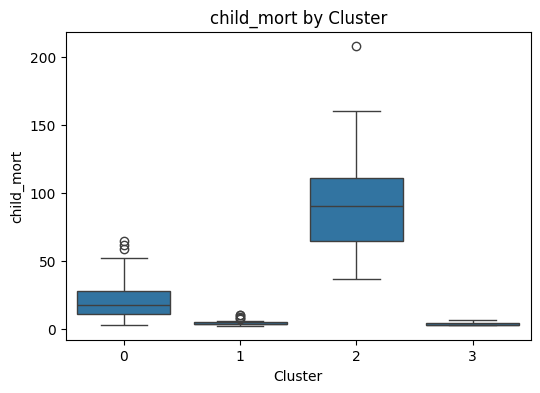

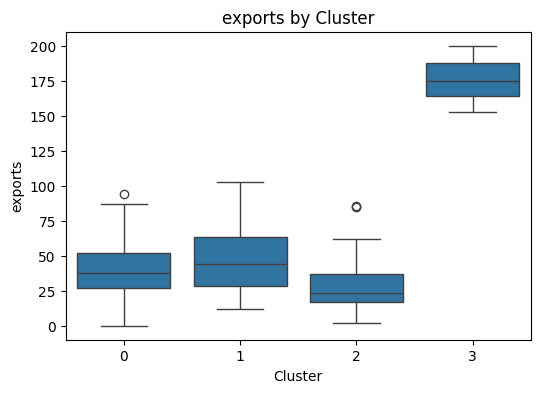

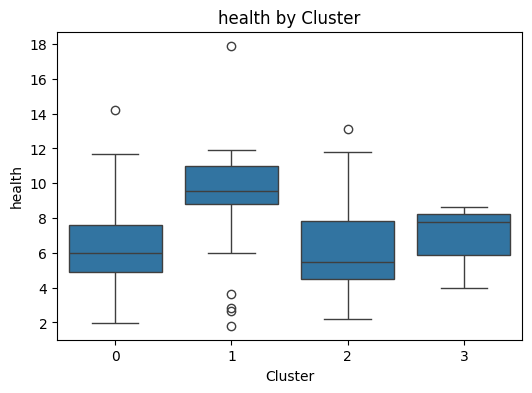

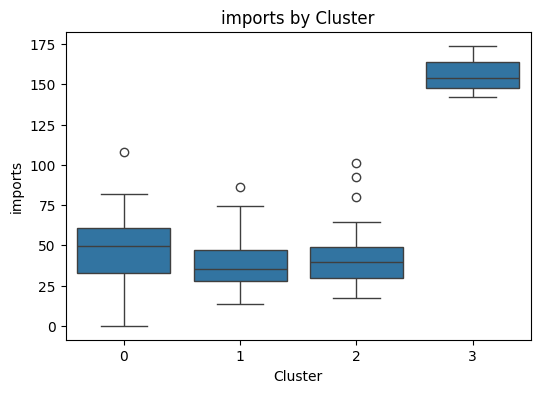

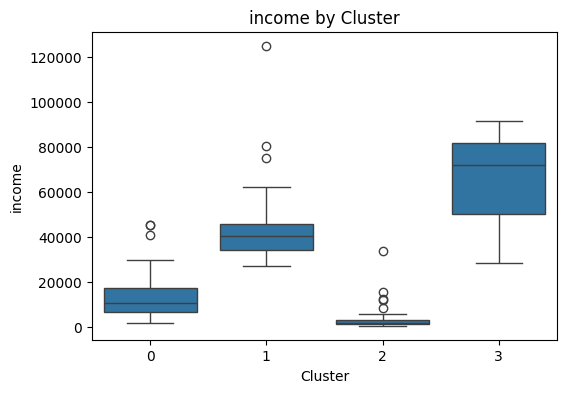

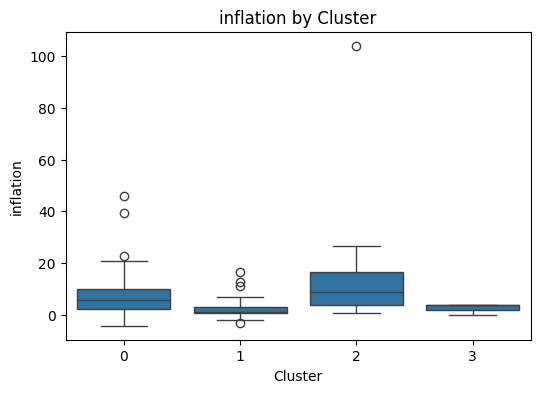

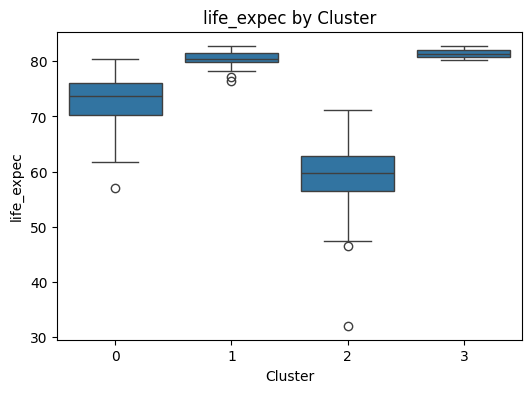

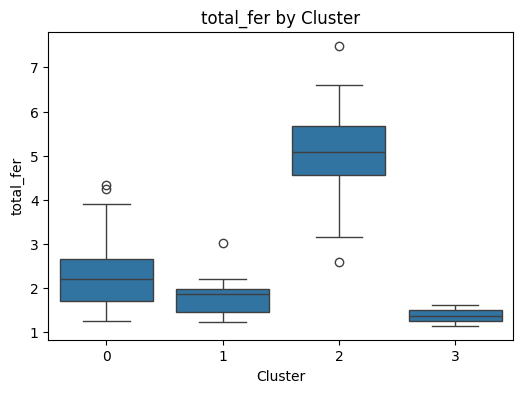

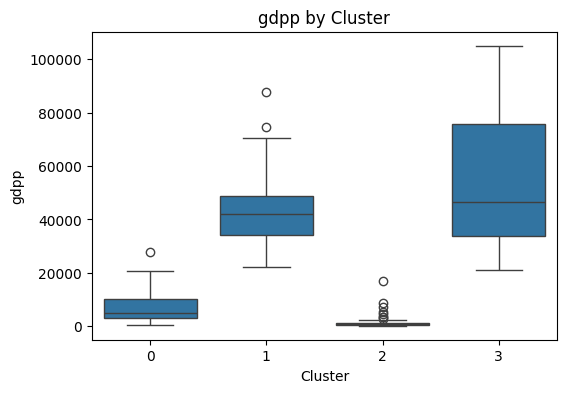

In [57]:
for col in X.columns:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        x='Cluster',
        y=col,
        data=df
    )

    plt.title(f'{col} by Cluster')

    plt.show()

# Identifying Countries Requiring Aid

Countries with:

- Low income
- Low GDP
- High child mortality
- Low life expectancy

are likely to require immediate financial assistance.

In [58]:
aid_cluster = cluster_summary[
    "income"
].idxmin()

aid_cluster

np.int32(2)

In [59]:
aid_countries = df[
    df["Cluster"] == aid_cluster
]

aid_countries[
    [
        "country",
        "income",
        "gdpp",
        "child_mort",
        "life_expec"
    ]
].sort_values(
    by="income"
).head(20)

,country,income,gdpp,child_mort,life_expec
37,"Congo, Dem. Rep.",609,334,116.0,57.5
88,Liberia,700,327,89.3,60.8
26,Burundi,764,231,93.6,57.7
112,Niger,814,348,123.0,58.8
31,Central African Republic,888,446,149.0,47.5
106,Mozambique,918,419,101.0,54.5
94,Malawi,1030,459,90.5,53.1
63,Guinea,1190,648,109.0,58.0
150,Togo,1210,488,90.3,58.7
132,Sierra Leone,1220,399,160.0,55.0


In [60]:
# Final Insights

highest_child_mort_cluster = cluster_summary['child_mort'].idxmax()

highest_income_cluster = cluster_summary['income'].idxmax()

highest_gdpp_cluster = cluster_summary['gdpp'].idxmax()

underdeveloped_cluster = cluster_summary['income'].idxmin()

print("FINAL INSIGHTS")
print("-"*50)

print(f"Cluster {highest_child_mort_cluster} has the highest child mortality rate.")

print(f"Cluster {highest_income_cluster} has the highest average income.")

print(f"Cluster {highest_gdpp_cluster} has the highest GDP per capita.")

print(f"Cluster {underdeveloped_cluster} appears to be the most underdeveloped cluster.")

print(f"Countries in Cluster {aid_cluster} should be prioritized for aid.")

FINAL INSIGHTS
--------------------------------------------------
Cluster 2 has the highest child mortality rate.
Cluster 3 has the highest average income.
Cluster 3 has the highest GDP per capita.
Cluster 2 appears to be the most underdeveloped cluster.
Countries in Cluster 2 should be prioritized for aid.


# Final Insights

1. Cluster 2 has the highest child mortality rate, indicating poor healthcare conditions.

2. Cluster 3 has the highest income and GDP per capita, representing developed countries.

3. Cluster 2 appears to be the most underdeveloped cluster due to low income and low GDP levels.

4. Countries belonging to Cluster 2 should be prioritized for financial aid and development programs.

5. The clustering approach successfully segmented countries based on socio-economic indicators and can support data-driven aid allocation.

# Top Priority Countries

To prioritize aid allocation, we create a simple aid score based on child mortality, fertility rate, and life expectancy.

Higher scores indicate countries facing greater socio-economic challenges.

In [61]:
aid_countries = aid_countries.copy()

aid_countries["Aid_Score"] = (
    aid_countries["child_mort"]
    + aid_countries["total_fer"]
    - aid_countries["life_expec"]
)

top10 = aid_countries.sort_values(
    by="Aid_Score",
    ascending=False
)

top10[
    [
        "country",
        "Aid_Score",
        "income",
        "gdpp",
        "child_mort",
        "life_expec"
    ]
].head(10)

,country,Aid_Score,income,gdpp,child_mort,life_expec
66,Haiti,179.23,1500,662,208.0,32.1
132,Sierra Leone,110.20,1220,399,160.0,55.0
31,Central African Republic,106.71,888,446,149.0,47.5
32,Chad,100.09,1930,897,150.0,56.5
97,Mali,84.05,1870,708,137.0,59.5
113,Nigeria,75.34,5150,2330,130.0,60.5
112,Niger,71.69,814,348,123.0,58.8
3,Angola,65.06,5900,3530,119.0,60.1
37,"Congo, Dem. Rep.",65.04,609,334,116.0,57.5
25,Burkina Faso,63.97,1430,575,116.0,57.9


# Saving Pipeline Components

Saving trained components allows us to reuse the pipeline without retraining.

In [62]:
joblib.dump(
    scaler,
    "scaler.pkl"
)

joblib.dump(
    pca,
    "pca.pkl"
)

joblib.dump(
    kmeans,
    "kmeans_model.pkl"
)

print("Pipeline Saved Successfully")

Pipeline Saved Successfully


# Creating an Inference Function

This function can be used to predict the cluster of a new country based on its socio-economic indicators.

In [63]:
def predict_cluster(new_data):

    scaled = scaler.transform(new_data)

    transformed = pca.transform(scaled)

    prediction = kmeans.predict(transformed)

    return prediction

# Business Recommendations

Based on clustering results, countries belonging to the low-income cluster should be prioritized for aid.

Key characteristics of these countries:

- Low GDP per capita
- Low income levels
- High child mortality
- Lower life expectancy
- Higher fertility rates

HELP International can use these insights to allocate resources more effectively and maximize social impact.

# Conclusion

In this project, we developed an end-to-end unsupervised machine learning pipeline to segment countries based on socio-economic and health indicators.

Key steps performed:

- Data validation and cleaning
- Exploratory Data Analysis
- Feature scaling
- PCA-based dimensionality reduction
- K-Means clustering
- Cluster evaluation using Silhouette Score
- Cluster profiling
- Identification of countries requiring financial aid

The analysis helps HELP International prioritize aid distribution to countries facing the greatest socio-economic challenges.